# RL Agent Training Tutorial

This notebook guides you through training a reinforcement learning agent to learn quantum noise models. We'll start with a simple single-circuit example and gradually build up to training on complex multi-qubit datasets.

## 1. Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch

# Import RL Noise components
from rlnoise.config import (
    DatasetConfig,
    NoiseConfig,
    GateSpecificNoise,
    GymEnvConfig,
    RewardConfig,
    AgentConfig,
)
from rlnoise.dataset import DatasetGenerator, CircuitDataset
from rlnoise.circuit_encoder import CircuitEncoder
from rlnoise.gym_env import QuantumCircuitEnv
from rlnoise.rl_agent import RLAgent

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)


## 2. Understanding the Training Components

Before we start training, let's understand the key components:

### 2.1 Neural Network Architecture

The agent uses a **CNN Feature Extractor** that processes the sliding window observations:
- **Input**: Sliding window of circuit moments (shape: encoding_dim × n_qubits × kernel_size)
- **Conv2D Layer**: Extracts spatial features from the circuit
- **Flatten + Linear**: Maps features to a fixed dimension
- **Policy & Value Networks**: Separate networks for action selection and value estimation

### 2.2 Training Callback

The callback monitors training progress:
- Periodically evaluates the agent on train/validation sets
- Tracks metrics (reward, trace distance, etc.)
- Saves the best model based on validation performance
- Provides real-time feedback during training

### 2.3 Agent Configuration

The `AgentConfig` controls:
- **features_dim**: Output dimension of feature extractor
- **filter_size**: CNN filter width
- **n_filters**: Number of CNN filters
- **n_steps**: Steps before PPO update
- **batch_size**: Batch size for training
- **learning_rate**: Optimizer learning rate

## 3. Simple Training Example: Single Circuit

Let's start with the simplest possible case: a single 1-qubit circuit with only one source of coherent noise.

### 3.1. Create a Simple Dataset

In [2]:
# Create a very simple dataset - 1 circuit, 1 qubit
simple_dataset_config = DatasetConfig(
    n_circuits=1,
    moments=8,
    qubits=1,
    primitive_gates=["rx", "rz"],
    clifford=True
)

noise_parameter = 0.06  # coherent noise level for the simple model

# Simple noise model - only depolarizing with a clear value
simple_noise_config = NoiseConfig(
    noise_list=[
        GateSpecificNoise(gate="rx", noise_channel="coherent_x", noise_parameter=noise_parameter),
        GateSpecificNoise(gate="rz", noise_channel="coherent_x", noise_parameter=noise_parameter),
    ]
)

# Generate the dataset
generator = DatasetGenerator(simple_dataset_config, simple_noise_config)
simple_dataset = generator.generate(verbose=True)

print(simple_dataset)

[Qibo 0.2.23|INFO|2026-04-02 13:14:48]: Using numpy backend on /CPU:0


Generating 1 circuits...
Applying noise model...
Encoding circuits...
Dataset generated.

  CircuitDataset
    • Circuits:            1
    • Qubits:              1
    • Moments (depth):     8
    • Encoding dimension:  8
    • Circuit shape:       (8, 1, 8)


### 3.2. Create Environment and Encoder

In [3]:
# Create encoder
simple_encoder = CircuitEncoder(primitive_gates=["rx", "rz"])

# Environment configuration
simple_env_config = GymEnvConfig(
    kernel_size=3,
    action_space_max_value=0.1,     # Max noise per step: 0.1
    val_split=0.0,              # No validation split for single circuit
)

# Reward configuration
simple_reward_config = RewardConfig(
    metric="trace",
    function="inverted_squared",
    alpha=20.0
)

# Create environment
simple_env = QuantumCircuitEnv(
    dataset=simple_dataset,
    encoder=simple_encoder,
    env_config=simple_env_config,
    reward_config=simple_reward_config,
)

print(simple_env)

QuantumCircuitEnv:
  Dataset:
    circuits: 1 (1 train, 0 val)
    qubits: 1
  Encoder:
    primitive_gates: ['rx', 'rz']
  Environment:
    observation_space: (8, 1, 3)
    action_space: (1, 4)
    kernel_size: 3
    action_max: 0.1
    only_depolarizing: False
  Reward:
    metric: trace
    function: inverted_squared
    alpha: 20.0


### 3.3. Configure the Agent

For this simple task, we'll use a small neural network.

In [4]:
# Agent configuration - small network for simple task
simple_agent_config = AgentConfig(
    policy="MlpPolicy",
    features_dim=32,        # Number of features extracted by CNN
    filter_size=2,          # Size of convolutional filters
    n_filters=16,           # Number of filters
    pi_net_arch=[32],       # Simple policy network
    vf_net_arch=[32],       # Simple value network
    n_steps=400,            # Update every 400 steps
    batch_size=50,          # Small batches (has to divide steps)
    learning_rate=1e-4,
    verbose=1
)

simple_agent = RLAgent(
    env=simple_env,
    agent_config=simple_agent_config
)

print(simple_agent)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
RLAgent (PPO)
  Observation space:    (8, 1, 3)
  Action space:         (1, 4)
  Action range:         [0.000, 1.000]
------------------------------------------------------------
  Total parameters:     3,609
  Trainable parameters: 3,609
------------------------------------------------------------
  Features dim:         32
  CNN filters:          16
  CNN filter size:      2
  Policy net arch:      [32]
  Value net arch:       [32]
------------------------------------------------------------
  Learning rate:        0.0001
  Batch size:           50
  N steps:              400
  Gamma:                0.99


For more information about the neural network:

In [54]:
simple_agent.print_network()

NEURAL NETWORK ARCHITECTURE

ActorCriticPolicy(
  (features_extractor): CNNFeaturesExtractor(
    (conv1): Conv2d(8, 16, kernel_size=(1, 2), stride=(1, 1))
    (cnn): Sequential(
      (0): Conv2d(8, 16, kernel_size=(1, 2), stride=(1, 1))
      (1): ReLU()
      (2): Flatten(start_dim=1, end_dim=-1)
    )
    (linear): Sequential(
      (0): Linear(in_features=32, out_features=32, bias=True)
      (1): ReLU()
    )
  )
  (pi_features_extractor): CNNFeaturesExtractor(
    (conv1): Conv2d(8, 16, kernel_size=(1, 2), stride=(1, 1))
    (cnn): Sequential(
      (0): Conv2d(8, 16, kernel_size=(1, 2), stride=(1, 1))
      (1): ReLU()
      (2): Flatten(start_dim=1, end_dim=-1)
    )
    (linear): Sequential(
      (0): Linear(in_features=32, out_features=32, bias=True)
      (1): ReLU()
    )
  )
  (vf_features_extractor): CNNFeaturesExtractor(
    (conv1): Conv2d(8, 16, kernel_size=(1, 2), stride=(1, 1))
    (cnn): Sequential(
      (0): Conv2d(8, 16, kernel_size=(1, 2), stride=(1, 1))
     

### 3.4. Train the Agent

Now let's create the agent and train it!

In [5]:
import importlib, rlnoise.callback, rlnoise.rl_agent
importlib.reload(rlnoise.callback)
importlib.reload(rlnoise.rl_agent)
from rlnoise.rl_agent import RLAgent

# Re-create agent to pick up reloaded modules
simple_agent = RLAgent(env=simple_env, agent_config=simple_agent_config)

# Train the agent
results = simple_agent.train(
    total_timesteps=20001,           # Short training for simple task
    check_freq=2000,                 # Performance evaluation frequency (in steps)
    save_best=True,                 # Don't save for this demo
    progress_bar=True,
    verbose=True,                    # Print avg reward at each eval step
    deterministic_train_eval=True,   # Full deterministic pass over train set (False = faster rollout accumulation)
)


Output()

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Step    2000 | Train reward: 5.5489 ± 0.0000  trace: 0.0949 ± 0.0000  |  Val reward: 0.0000 ± 0.0000  trace: 0.0000 ± 0.0000


Step    4000 | Train reward: 5.6079 ± 0.0000  trace: 0.0944 ± 0.0000  |  Val reward: 0.0000 ± 0.0000  trace: 0.0000 ± 0.0000


Step    6000 | Train reward: 8.1982 ± 0.0000  trace: 0.0781 ± 0.0000  |  Val reward: 0.0000 ± 0.0000  trace: 0.0000 ± 0.0000


...

Step   14000 | Train reward: 58.6513 ± 0.0000  trace: 0.0292 ± 0.0000  |  Val reward: 0.0000 ± 0.0000  trace: 0.0000 ± 0.0000


Step   16000 | Train reward: 92.7981 ± 0.0000  trace: 0.0232 ± 0.0000  |  Val reward: 0.0000 ± 0.0000  trace: 0.0000 ± 0.0000


Step   18000 | Train reward: 200.4295 ± 0.0000  trace: 0.0158 ± 0.0000  |  Val reward: 0.0000 ± 0.0000  trace: 0.0000 ± 0.0000


Step   20000 | Train reward: 655.1894 ± 0.0000  trace: 0.0087 ± 0.0000  |  Val reward: 0.0000 ± 0.0000  trace: 0.0000 ± 0.0000


Loaded best model weights.


### 3.5. Analyze Training Results

The error bars are not shown as only one sample is available

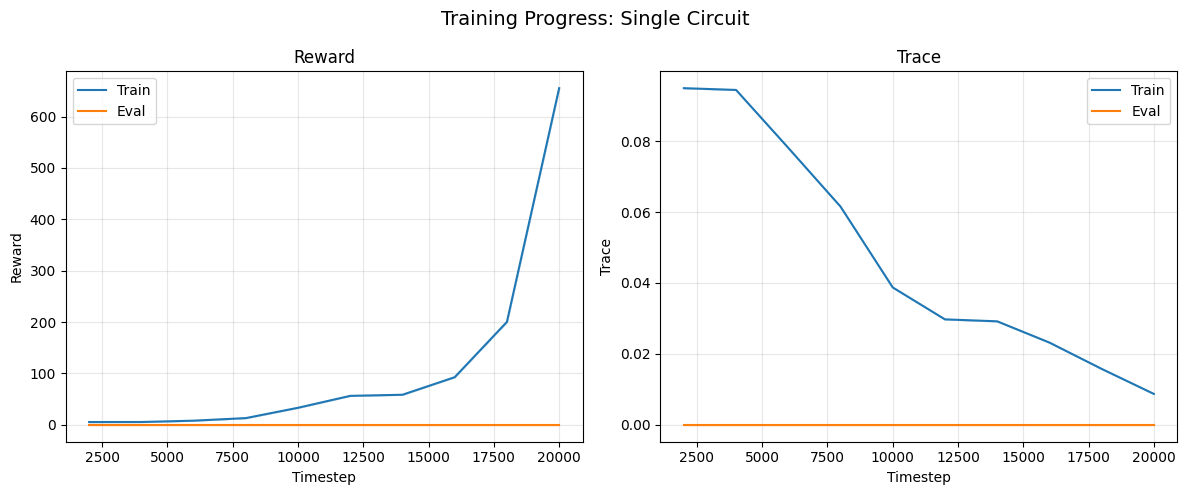

In [6]:
from rlnoise.visualization import plot_training_dashboard

fig = plot_training_dashboard(results, title="Training Progress: Single Circuit", filepath="training_results/single_circuit_dashboard.png",)
plt.show()


### 3.6. Test the Trained Agent

Let's see what noise parameters the agent learned to apply!

In [7]:
# Reset environment and run an episode with the trained agent
obs, info = simple_env.reset()

actions_taken = []
step = 0
terminated = False

print("Target noise: ", noise_parameter)
print()

while not terminated:
    # Get action from trained agent
    action = simple_agent.predict(obs, deterministic=True)
    actions_taken.append(action)
    
    # Show what action was taken
    
    x_action = action[0, 0]  # Index 0 is coherent X
    print(f"Step {step}: Coherent rx action = {x_action:.4f} → noise = {x_action * 0.1:.4f}")

    print("Full action:\n", action)
    
    # Take step
    obs, reward, terminated, truncated, info = simple_env.step(action)
    step += 1

Target noise:  0.06

Step 0: Coherent rx action = 0.5086 → noise = 0.0509
Full action:
 [[0.5085937 0.        0.        0.       ]]
Step 1: Coherent rx action = 0.5457 → noise = 0.0546
Full action:
 [[0.54567885 0.         0.         0.        ]]
Step 2: Coherent rx action = 0.5350 → noise = 0.0535
Full action:
 [[0.534999 0.       0.       0.      ]]
Step 3: Coherent rx action = 0.5084 → noise = 0.0508
Full action:
 [[0.50844234 0.         0.         0.        ]]
Step 4: Coherent rx action = 0.5467 → noise = 0.0547
Full action:
 [[0.5467178 0.        0.        0.       ]]
Step 5: Coherent rx action = 0.5399 → noise = 0.0540
Full action:
 [[0.5399216 0.        0.        0.       ]]
Step 6: Coherent rx action = 0.5139 → noise = 0.0514
Full action:
 [[0.51388216 0.         0.         0.        ]]
Step 7: Coherent rx action = 0.5367 → noise = 0.0537
Full action:
 [[0.53674036 0.         0.         0.        ]]


## 4. Training with Multiple Circuits

Now let's scale up to multiple circuits to see how the agent generalizes.

### 4.1. Create Multi-Circuit Dataset

In [ ]:
multi_dataset_config = DatasetConfig(
    n_circuits=100,
    moments=10,
    qubits=1,
    primitive_gates=["rz", "rx"],
    clifford=True,
    distributed_clifford=False,
    mixed=False,
)

# More complex noise model with multiple noise channels and different parameters on rx and rz, matching experiments/simulation/1q/config.json
multi_noise_config = NoiseConfig(
    noise_list=[
        GateSpecificNoise(gate="rz", noise_channel="depolarizing",  noise_parameter=0.02),
        GateSpecificNoise(gate="rx", noise_channel="damping",       noise_parameter=0.03),
        GateSpecificNoise(gate="rx", noise_channel="coherent_x",    noise_parameter=0.04),
        GateSpecificNoise(gate="rz", noise_channel="coherent_z",    noise_parameter=0.02),
    ]
)

generator = DatasetGenerator(multi_dataset_config, multi_noise_config)
multi_dataset = generator.generate(verbose=True)

print(multi_dataset)


Generating 100 circuits...
Applying noise model...
Encoding circuits...
Dataset generated.

  CircuitDataset
    • Circuits:            100
    • Qubits:              1
    • Moments (depth):     10
    • Encoding dimension:  8
    • Circuit shape:       (10, 1, 8)


### 4.2. Setup Environment with Validation Split

In [10]:

multi_encoder = CircuitEncoder(primitive_gates=["rz", "rx"])

# Env config from 1q config.json
multi_env_config = GymEnvConfig(
    kernel_size=3,
    action_penalty=0.0,
    action_space_max_value=0.06,
    enable_only_depolarizing=False,
    val_split=0.2,
)

multi_reward_config = RewardConfig(
    metric="trace",
    function="inverted_squared",
    alpha=20.0,
)

multi_env = QuantumCircuitEnv(
    dataset=multi_dataset,
    encoder=multi_encoder,
    env_config=multi_env_config,
    reward_config=multi_reward_config,
)

print(multi_env)


QuantumCircuitEnv:
  Dataset:
    circuits: 100 (80 train, 20 val)
    qubits: 1
  Encoder:
    primitive_gates: ['rz', 'rx']
  Environment:
    observation_space: (8, 1, 3)
    action_space: (1, 4)
    kernel_size: 3
    action_max: 0.06
    only_depolarizing: False
  Reward:
    metric: trace
    function: inverted_squared
    alpha: 20.0


### 4.3. Train with Callback Monitoring

In [15]:

# Agent config from 1q config.json:
#   policy=MlpPolicy, features_dim=32, filter_size=1, n_filters=16,
#   net_arch pi=[32,32] vf=[32,32], nn_update_steps=1000, batch_size=200
multi_agent_config = AgentConfig(
    policy="MlpPolicy",
    features_dim=32,
    filter_size=1,
    n_filters=16,
    pi_net_arch=[32, 32],
    vf_net_arch=[32, 32],
    n_steps=2000,
    batch_size=200,
    learning_rate=1e-4,
)

multi_agent = RLAgent(
    env=multi_env,
    agent_config=multi_agent_config
)

print(multi_agent)

multi_results = multi_agent.train(
    total_timesteps=200000,
    check_freq=10000,
    save_best=True,
    progress_bar=True,
    verbose=True,
    save_path="agents/1q_agent",
)


Output()

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
RLAgent (PPO)
  Observation space:    (8, 1, 3)
  Action space:         (1, 4)
  Action range:         [0.000, 1.000]
------------------------------------------------------------
  Total parameters:     6,105
  Trainable parameters: 6,105
------------------------------------------------------------
  Features dim:         32
  CNN filters:          16
  CNN filter size:      1
  Policy net arch:      [32, 32]
  Value net arch:       [32, 32]
------------------------------------------------------------
  Learning rate:        0.0001
  Batch size:           200
  N steps:              2000
  Gamma:                0.99


Step   10000 | Train reward: 3.0886 ± 0.7244  trace: 0.1301 ± 0.0166  |  Val reward: 3.3349 ± 0.8983  trace: 0.1264 ± 0.0196
Model saved in agents/1q_agent


Step   20000 | Train reward: 3.3219 ± 0.7676  trace: 0.1251 ± 0.0145  |  Val reward: 3.5258 ± 0.8900  trace: 0.1222 ± 0.0164
Model saved in agents/1q_agent


Step   30000 | Train reward: 3.4416 ± 0.8122  trace: 0.1229 ± 0.0138  |  Val reward: 3.6031 ± 0.8577  trace: 0.1204 ± 0.0148
Model saved in agents/1q_agent


...

Step  170000 | Train reward: 12.1612 ± 7.4539  trace: 0.0693 ± 0.0139  |  Val reward: 11.8926 ± 3.4562  trace: 0.0671 ± 0.0103


Step  180000 | Train reward: 43.2966 ± 156.5657  trace: 0.0494 ± 0.0140  |  Val reward: 25.3966 ± 9.8830  trace: 0.0469 ± 0.0090


Step  190000 | Train reward: 31.9059 ± 69.4606  trace: 0.0506 ± 0.0138  |  Val reward: 23.8717 ± 9.0234  trace: 0.0482 ± 0.0090


Step  200000 | Train reward: 33.3087 ± 99.3549  trace: 0.0521 ± 0.0139  |  Val reward: 22.9718 ± 8.9510  trace: 0.0494 ± 0.0095


Loaded best model weights from agents/1q_agent


### 4.4. Analyze Multi-Circuit Training

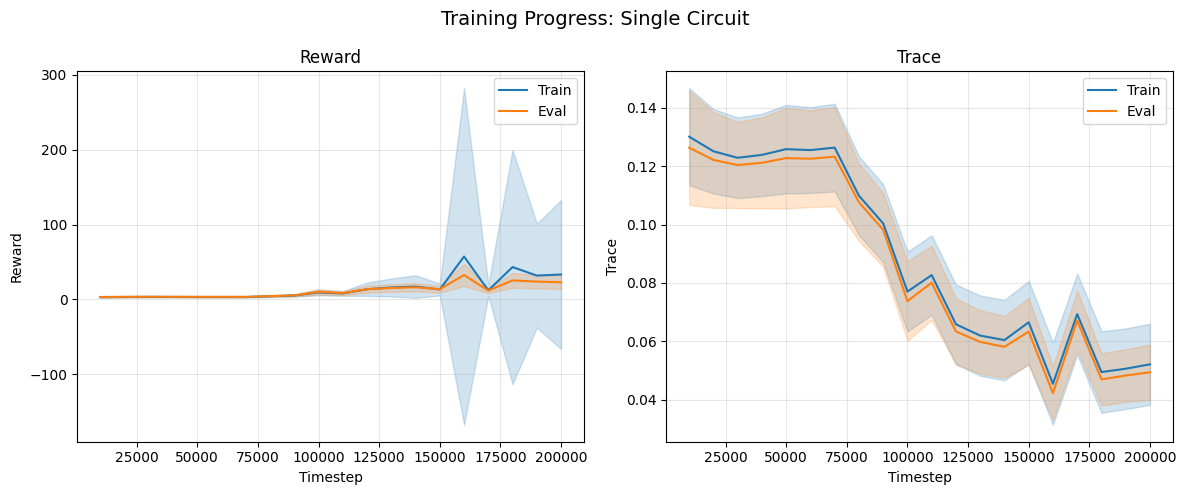

In [16]:
fig = plot_training_dashboard(multi_results, title="Training Progress: Single Circuit", filepath="training_results/single_circuit_complex_dashboard.png",)
plt.show()

## 5. Advanced: 3-Qubit Training

Now for the final challenge - training on 3-qubit circuits with multiple noise types!

### 5.1. Load 3-Qubit Dataset

We'll use a pre-generated 3-qubit dataset from the examples folder or generate it if not present. The characteristics of the dataset are the same used in the 3 qubit experiment.

In [3]:

DATASET_3Q_PATH = Path("example_datasets/dataset_3q_large.npz")

if DATASET_3Q_PATH.exists():
    print(f"Loading existing dataset from '{DATASET_3Q_PATH}'...")
    dataset_3q = CircuitDataset.load(str(DATASET_3Q_PATH))
else:
    print("Dataset not found, generating...")

    dataset_config_3q = DatasetConfig(
        n_circuits=800,
        moments=20,
        qubits=3,
        primitive_gates=["rz", "rx", "cz"],
        clifford=False,
        distributed_clifford=False,
        mixed=True,
    )

    noise_config_3q = NoiseConfig(
        noise_list=[
            GateSpecificNoise(gate="rz", noise_channel="depolarizing", noise_parameter=0.02),
            GateSpecificNoise(gate="cz", noise_channel="depolarizing", noise_parameter=0.02),
            GateSpecificNoise(gate="rx", noise_channel="damping",       noise_parameter=0.03),
            GateSpecificNoise(gate="cz", noise_channel="damping",       noise_parameter=0.03),
            GateSpecificNoise(gate="rx", noise_channel="coherent_x",    noise_parameter=0.04),
            GateSpecificNoise(gate="rz", noise_channel="coherent_z",    noise_parameter=0.03),
        ]
    )

    print(noise_config_3q)

    generator_3q = DatasetGenerator(dataset_config_3q, noise_config_3q)
    dataset_3q = generator_3q.generate(verbose=True)

    dataset_3q.save(str(DATASET_3Q_PATH))
    print(f"Dataset saved to '{DATASET_3Q_PATH}'")

print(dataset_3q)


Dataset not found, generating...

  NoiseConfig
  Gate-Specific Noise:
    Gate: cz
      • depolarizing: 0.0200
      • damping: 0.0300
    Gate: rx
      • damping: 0.0300
      • coherent_x: 0.0400
    Gate: rz
      • depolarizing: 0.0200
      • coherent_z: 0.0300
Generating 800 circuits...


[Qibo 0.2.23|INFO|2026-04-02 13:39:41]: Using numpy backend on /CPU:0


Applying noise model...
Encoding circuits...
Dataset generated.
Dataset saved to 'example_datasets\dataset_3q_large.npz'

  CircuitDataset
    • Circuits:            800
    • Qubits:              3
    • Moments (depth):     20
    • Encoding dimension:  8
    • Circuit shape:       variable (sample: (20, 3, 8))


### 5.2. Setup 3-Qubit Environment

In [4]:
# Create encoder for 3-qubit circuits
encoder_3q = CircuitEncoder(primitive_gates=["rx", "rz", "cz"])

# Environment configuration
env_config_3q = GymEnvConfig(
    kernel_size=3,
    action_space_max_value=0.06,  # Max noise per step: 0.06
    val_split=0.2,
    enable_only_depolarizing=False,  # Allow all noise types
)

# Reward configuration
reward_config_3q = RewardConfig(
    metric="trace",
    function="inverted_squared",
    alpha=20.0
)

# Create environment
env_3q = QuantumCircuitEnv(
    dataset=dataset_3q,
    encoder=encoder_3q,
    env_config=env_config_3q,
    reward_config=reward_config_3q,
)

print(env_3q)

QuantumCircuitEnv:
  Dataset:
    circuits: 800 (640 train, 160 val)
    qubits: 3
  Encoder:
    primitive_gates: ['rx', 'rz', 'cz']
  Environment:
    observation_space: (8, 3, 3)
    action_space: (3, 4)
    kernel_size: 3
    action_max: 0.06
    only_depolarizing: False
  Reward:
    metric: trace
    function: inverted_squared
    alpha: 20.0


### 5.3. Configure Agent for 3-Qubit Circuits

For 3-qubit circuits, we need a larger network to handle the complexity.

In [5]:

# Agent config from 3q_high config.json:
#   policy=MlpPolicy, features_dim=64, filter_size=1, n_filters=32,
#   net_arch pi=[32,32] vf=[32,32], nn_update_steps=2000, batch_size=400
agent_config_3q = AgentConfig(
    policy="MlpPolicy",
    features_dim=64,
    filter_size=1,
    n_filters=32,
    pi_net_arch=[32, 32],
    vf_net_arch=[32, 32],
    n_steps=4000,
    batch_size=400,
)

agent_3q = RLAgent(
    env=env_3q,
    agent_config=agent_config_3q
)

print(agent_3q)


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
RLAgent (PPO)
  Observation space:    (8, 3, 3)
  Action space:         (3, 4)
  Action range:         [0.000, 1.000]
------------------------------------------------------------
  Total parameters:     13,721
  Trainable parameters: 13,721
------------------------------------------------------------
  Features dim:         64
  CNN filters:          32
  CNN filter size:      1
  Policy net arch:      [32, 32]
  Value net arch:       [32, 32]
------------------------------------------------------------
  Learning rate:        0.0003
  Batch size:           400
  N steps:              4000
  Gamma:                0.99


### 5.4. Train 3-Qubit Agent

This will take longer due to the increased complexity. For a proper training order of 10^6 timestps should be executed.

In [ ]:

# Train: 2 000 000 steps, eval every 10 000 (from 3q_high callback.check_freq)
results_3q = agent_3q.train(
    total_timesteps=2000000,
    check_freq=10000,
    save_best=True,
    progress_bar=True,
    verbose=True,
    save_path="agents/3q_agent_long_training",
)


Output()

[Qibo 0.2.23|INFO|2026-04-01 18:56:59]: Using numpy backend on /CPU:0


Step  100000 | Train reward: 0.6957 ± 1.6812  trace: 0.4795 ± 0.1666  |  Val reward: 1.2327 ± 2.2246  trace: 0.3980 ± 0.1908
Model saved in agents/3q_agent_long_training


Step  200000 | Train reward: 0.6574 ± 1.3925  trace: 0.4713 ± 0.1648  |  Val reward: 1.2389 ± 2.0480  trace: 0.3936 ± 0.1876


Model saved in agents/3q_agent_long_training


...

Step 1700000 | Train reward: 0.9462 ± 2.2159  trace: 0.4291 ± 0.1583  |  Val reward: 0.9035 ± 1.3738  trace: 0.3678 ± 0.1454


Step 1800000 | Train reward: 0.8509 ± 2.1818  trace: 0.4339 ± 0.1556  |  Val reward: 0.8487 ± 1.2616  trace: 0.3729 ± 0.1433


Step 1900000 | Train reward: 0.9978 ± 2.6878  trace: 0.4377 ± 0.1609  |  Val reward: 0.8240 ± 1.1707  trace: 0.3760 ± 0.1532


Step 2000000 | Train reward: 1.0448 ± 2.6377  trace: 0.4387 ± 0.1639  |  Val reward: 0.6669 ± 0.7653  trace: 0.3822 ± 0.1464


Loaded best model weights from agents/3q_agent_long_training


### 5.5. Visualize 3-Qubit Training Results

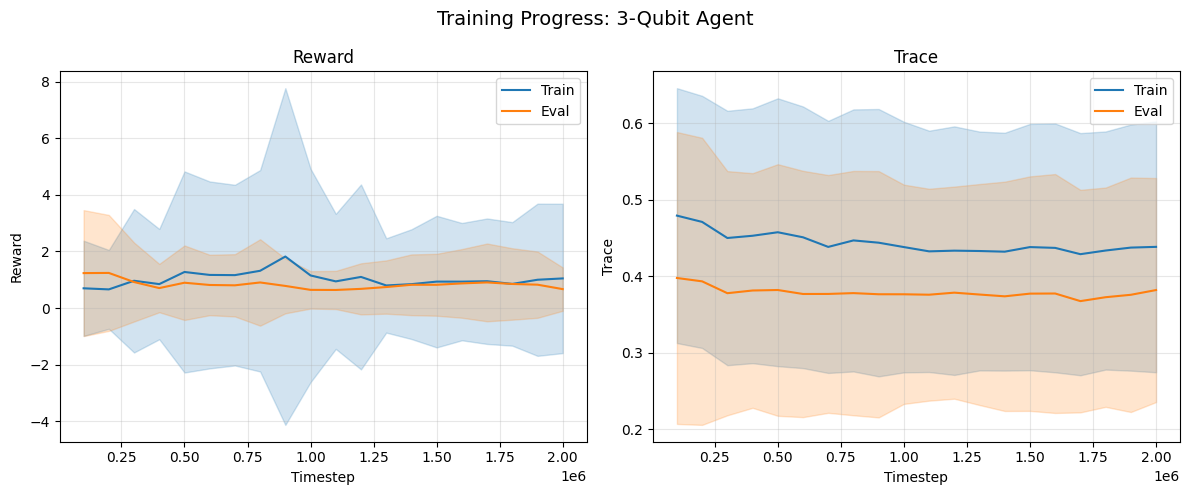

In [6]:
from rlnoise.visualization import plot_training_dashboard

fig = plot_training_dashboard(
    results_3q,
    title="Training Progress: 3-Qubit Agent",
    filepath="training_results/3q_dashboard.png",
)
plt.show()


### 5.6. Load and Apply Trained Agent to Circuits

In [77]:
SAVE_PATH = "agents/3q_agent"  # same path used in the training cell above

# ── 1. Load the saved agent ──────────────────────────────────────────────────
loaded_agent = RLAgent(
    env=env_3q,
    agent_config=agent_config_3q,
    model_path=SAVE_PATH,
)
print(f"Agent loaded from '{SAVE_PATH}'")

# ── 2. Pick a test circuit (first validation circuit) ────────────────────────
test_circuit_idx = env_3q.n_circuits_train
circuit_array    = dataset_3q.circuits[test_circuit_idx]
print(f"Test circuit index: {test_circuit_idx}  shape: {circuit_array.shape}")

# ── 3. Run a deterministic episode, recording actions per moment ─────────────
NOISE_LABELS = ["ε_x", "ε_z", "p_reset", "λ_depol"]
action_max    = env_3q.action_max
n_qubits      = env_3q.n_qubits

obs, _ = env_3q.reset(options={"circuit_idx": test_circuit_idx})
moment_actions = []          # list[(moment_idx, scaled_action)]
terminated = False
moment = 0

while not terminated:
    action = loaded_agent.predict(obs, deterministic=True)   # shape (n_qubits, 4)
    moment_actions.append((moment, action * action_max))     # store scaled values
    obs, reward, terminated, truncated, info = env_3q.step(action)
    moment += 1

# ── 4. Print a table for the first 3 moments ─────────────────────────────────
n_show = min(3, len(moment_actions))
col_w  = 10

header  = f"{'Moment':>7}  {'Qubit':>5}  " + "  ".join(f"{l:>{col_w}}" for l in NOISE_LABELS)
divider = "-" * len(header)

print(f"\nNoise actions for the first {n_show} moments (scaled values):")
print(divider)
print(header)
print(divider)
for m_idx, scaled_action in moment_actions[:n_show]:
    for q in range(n_qubits):
        values = "  ".join(f"{scaled_action[q, c]:>{col_w}.5f}" for c in range(4))
        qubit_label = f"q{q}"
        print(f"{m_idx:>7}  {qubit_label:>5}  {values}")
    print(divider)

print(f"\nFinal episode reward: {reward:.4f}")


Agent loaded from 'agents/3q_agent'
Test circuit index: 80  shape: (15, 3, 8)

Noise actions for the first 3 moments (scaled values):
--------------------------------------------------------------
 Moment  Qubit         ε_x         ε_z     p_reset     λ_depol
--------------------------------------------------------------
      0     q0     0.02268     0.00000     0.00000     0.00000
      0     q1     0.00000     0.02928     0.00000     0.08236
      0     q2     0.00000     0.02326     0.10000     0.04380
--------------------------------------------------------------
      1     q0     0.00000     0.00000     0.00000     0.05624
      1     q1     0.00000     0.00000     0.10000     0.01807
      1     q2     0.00670     0.00000     0.00000     0.00000
--------------------------------------------------------------
      2     q0     0.00000     0.00000     0.00000     0.01224
      2     q1     0.00000     0.01735     0.06931     0.04986
      2     q2     0.00000     0.00000     0.10